# House Price Prediction — 01: Exploratory Data Analysis

**Dataset:** California Housing (sklearn-derived CSV, sourced via Kaggle Learn / Ryan Holbrook's "Clustering with K-Means" notebook, manually downloaded — not the camnugent Kaggle dataset).

**Goal of this notebook:**
- Load and inspect the raw data
- Check data types, missing values, and basic statistics
- Understand the distribution of the target variable (`MedHouseVal`)
- Look at feature distributions and correlations
- Note any preprocessing decisions to carry into `02_data_preprocessing.ipynb`

## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
pd.set_option('display.max_columns', None)

print('Libraries loaded successfully.')

Libraries loaded successfully.


## 2. Load the Data

In [2]:
df = pd.read_csv('housing.csv')
print(f'Shape: {df.shape}')
df.head()

Shape: (20640, 9)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


## 3. Structure: Data Types & Non-Null Counts

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


## 4. Missing Values

Checking explicitly rather than assuming the dataset is clean.

In [4]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)

if missing_df.empty:
    print('No missing values found in any column.')
else:
    display(missing_df)

No missing values found in any column.


In [5]:
# Rows where ANY column has a null value (sanity check — should be 0 rows here)
df[df.isnull().any(axis=1)]

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal


## 5. Duplicate Rows

In [6]:
dupes = df.duplicated().sum()
print(f'Duplicate rows: {dupes}')

Duplicate rows: 0


## 6. Statistical Summary

In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
MedInc,20640.0,3.870671,1.899822,0.499900,2.563400,3.534800,4.743250,15.000100
HouseAge,20640.0,28.639486,12.585558,1.000000,18.000000,29.000000,37.000000,52.000000
AveRooms,20640.0,5.429000,2.474173,0.846154,4.440716,5.229129,6.052381,141.909091
AveBedrms,20640.0,1.096675,0.473911,0.333333,1.006079,1.048780,1.099526,34.066667
Population,20640.0,1425.476744,1132.462122,3.000000,787.000000,1166.000000,1725.000000,35682.000000
AveOccup,20640.0,3.070655,10.386050,0.692308,2.429741,2.818116,3.282261,1243.333333
Latitude,20640.0,35.631861,2.135952,32.540000,33.930000,34.260000,37.710000,41.950000
Longitude,20640.0,-119.569704,2.003532,-124.350000,-121.800000,-118.490000,-118.010000,-114.310000
MedHouseVal,20640.0,2.068558,1.153956,0.149990,1.196000,1.797000,2.647250,5.000010


**Things to watch for in `.describe()` output:**
- `AveRooms` / `AveBedrms` / `AveOccup` max values — are there extreme outliers (e.g. a block with 100+ average rooms)?
- `Population` range — sparse vs. dense block groups
- `MedHouseVal` — note the max value; the original sklearn dataset caps this at 5.00001 (capped/censored target), which matters for modeling later

In [12]:
df.nlargest(5, 'AveOccup')


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
19006,10.2264,45.0,3.166667,0.833333,7460.0,1243.333333,38.32,-121.98,1.375
3364,5.5179,36.0,5.142857,1.142857,4198.0,599.714286,40.41,-120.51,0.675
16669,4.2639,46.0,9.076923,1.307692,6532.0,502.461538,35.32,-120.70,3.500
13034,6.1359,52.0,8.275862,1.517241,6675.0,230.172414,38.69,-121.15,2.250
9172,4.2391,5.0,5.123810,0.933333,8733.0,83.171429,34.47,-118.59,1.546


In [13]:
df.loc[[19006, 3364, 16669, 13034, 9172]].assign(
    implied_households=lambda x: x['Population'] / x['AveOccup']
)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal,implied_households
19006,10.2264,45.0,3.166667,0.833333,7460.0,1243.333333,38.32,-121.98,1.375,6.0
3364,5.5179,36.0,5.142857,1.142857,4198.0,599.714286,40.41,-120.51,0.675,7.0
16669,4.2639,46.0,9.076923,1.307692,6532.0,502.461538,35.32,-120.70,3.500,13.0
13034,6.1359,52.0,8.275862,1.517241,6675.0,230.172414,38.69,-121.15,2.250,29.0
9172,4.2391,5.0,5.123810,0.933333,8733.0,83.171429,34.47,-118.59,1.546,105.0


In [14]:
(df['AveOccup'] > 10).sum()

np.int64(37)

In [15]:
df_filtered = df[df['AveOccup'] <= 10]
df_filtered[['AveRooms', 'AveBedrms', 'Population']].describe()

,AveRooms,AveBedrms,Population
count,20603.000000,20603.000000,20603.000000
mean,5.428533,1.096540,1423.339368
std,2.471073,0.473866,1128.241516
min,0.846154,0.333333,3.000000
25%,4.440829,1.006135,787.000000
50%,5.229682,1.048749,1166.000000
75%,6.052108,1.099418,1724.000000
max,141.909091,34.066667,35682.000000


In [16]:
df_filtered.nlargest(3, 'AveRooms')

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
1914,1.8750,33.0,141.909091,25.636364,30.0,2.727273,38.91,-120.10,5.00001
1979,4.6250,34.0,132.533333,34.066667,36.0,2.400000,38.80,-120.08,1.62500
12447,1.6154,17.0,62.422222,14.111111,83.0,1.844444,33.97,-114.49,0.87500


In [17]:
df_filtered.loc[[1914, 1979, 12447]].assign(
    implied_households=lambda x: x['Population'] / x['AveOccup'],
    total_rooms=lambda x: x['AveRooms'] * (x['Population'] / x['AveOccup'])
)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal,implied_households,total_rooms
1914,1.8750,33.0,141.909091,25.636364,30.0,2.727273,38.91,-120.10,5.00001,11.0,1561.0
1979,4.6250,34.0,132.533333,34.066667,36.0,2.400000,38.80,-120.08,1.62500,15.0,1988.0
12447,1.6154,17.0,62.422222,14.111111,83.0,1.844444,33.97,-114.49,0.87500,45.0,2809.0


In [18]:
df_filtered2 = df_filtered[df_filtered['AveRooms'] <= 20]
print(f"Rows removed in this step: {len(df_filtered) - len(df_filtered2)}")
df_filtered2[['AveRooms', 'AveBedrms', 'Population']].describe()

Rows removed in this step: 68


,AveRooms,AveBedrms,Population
count,20535.000000,20535.000000,20535.000000
mean,5.335105,1.077498,1427.048454
std,1.420036,0.197741,1128.128629
min,0.846154,0.333333,3.000000
25%,4.438131,1.005908,791.000000
50%,5.225127,1.048409,1168.000000
75%,6.041772,1.098592,1726.000000
max,19.962121,6.500000,35682.000000


In [19]:
df_filtered2['Population'].sort_values(ascending=False).head(20)

15360    35682.0
9880     28566.0
13139    16305.0
10309    16122.0
6057     15507.0
6066     15037.0
12215    13251.0
9019     12873.0
17413    12427.0
922      12203.0
9744     12153.0
9122     11973.0
20451    11956.0
12623    11935.0
9697     11272.0
13890    11139.0
6338     10988.0
15459    10877.0
9040     10493.0
9145     10475.0
Name: Population, dtype: float64

In [20]:
df_filtered2.nlargest(5, 'Population')[['Population', 'AveOccup', 'AveRooms', 'MedHouseVal', 'Latitude', 'Longitude']]

,Population,AveOccup,AveRooms,MedHouseVal,Latitude,Longitude
15360,35682.0,7.482072,5.270497,1.344,33.35,-117.42
9880,28566.0,4.696810,5.364518,1.188,36.64,-121.79
13139,16305.0,3.043113,7.338559,1.537,38.43,-121.44
10309,16122.0,3.106957,7.311043,3.663,33.89,-117.74
6057,15507.0,3.070693,6.347327,2.539,34.03,-117.78


In [21]:
# Outlier filtering based on EDA investigation:
# - AveOccup > 10: institutional/group housing (occupancy itself is implausible)
# - AveRooms > 20: tiny-household-count artifact inflating room average
#   (this also resolves the AveBedrms outliers as a side effect)

mask = (df['AveOccup'] <= 10) & (df['AveRooms'] <= 20)

df_clean = df[mask].copy()

rows_removed = len(df) - len(df_clean)
print(f"Rows removed: {rows_removed} ({rows_removed/len(df)*100:.2f}%)")
print(f"Remaining rows: {len(df_clean)}")

df_clean[['AveRooms', 'AveBedrms', 'Population', 'AveOccup']].describe()

Rows removed: 105 (0.51%)
Remaining rows: 20535


,AveRooms,AveBedrms,Population,AveOccup
count,20535.000000,20535.000000,20535.000000,20535.000000
mean,5.335105,1.077498,1427.048454,2.920374
std,1.420036,0.197741,1128.128629,0.765425
min,0.846154,0.333333,3.000000,0.750000
25%,4.438131,1.005908,791.000000,2.431048
50%,5.225127,1.048409,1168.000000,2.818966
75%,6.041772,1.098592,1726.000000,3.280652
max,19.962121,6.500000,35682.000000,9.954545


## 7. Target Variable Distribution: `MedHouseVal`

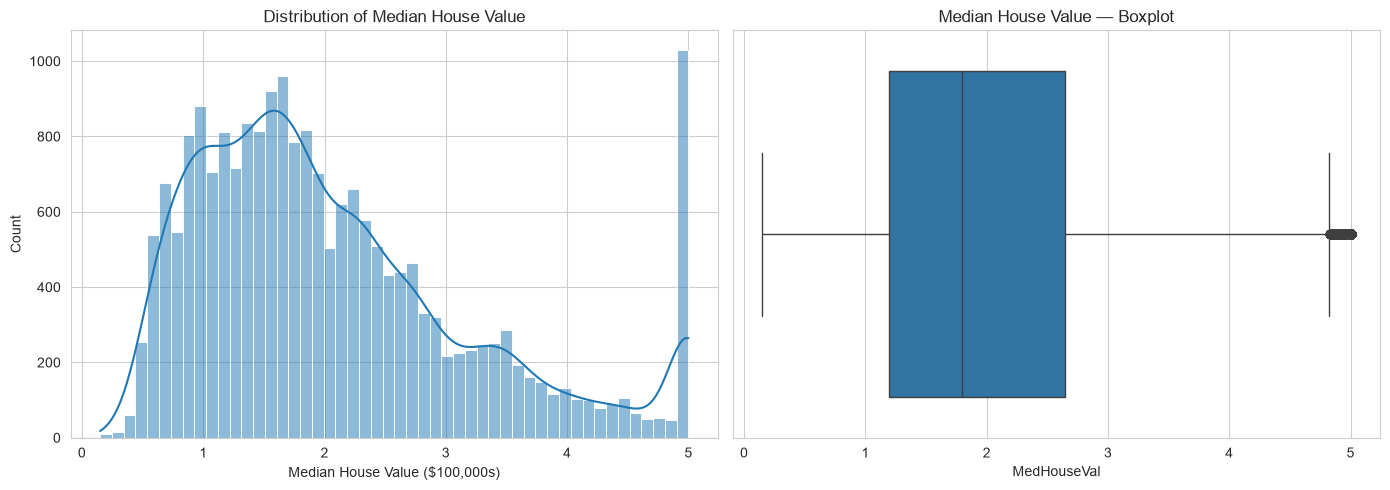

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df['MedHouseVal'], bins=50, kde=True, ax=axes[0])
axes[0].set_title('Distribution of Median House Value')
axes[0].set_xlabel('Median House Value ($100,000s)')

sns.boxplot(x=df['MedHouseVal'], ax=axes[1])
axes[1].set_title('Median House Value — Boxplot')

plt.tight_layout()
plt.savefig('outputs/target_distribution.png', dpi=150)
plt.show()

In [23]:
# Check how many rows sit at or near the capped max value
capped = (df['MedHouseVal'] >= 5.0).sum()
print(f'Rows with MedHouseVal >= 5.0: {capped} ({capped/len(df)*100:.2f}%)')

Rows with MedHouseVal >= 5.0: 992 (4.81%)


## 8. Feature Distributions

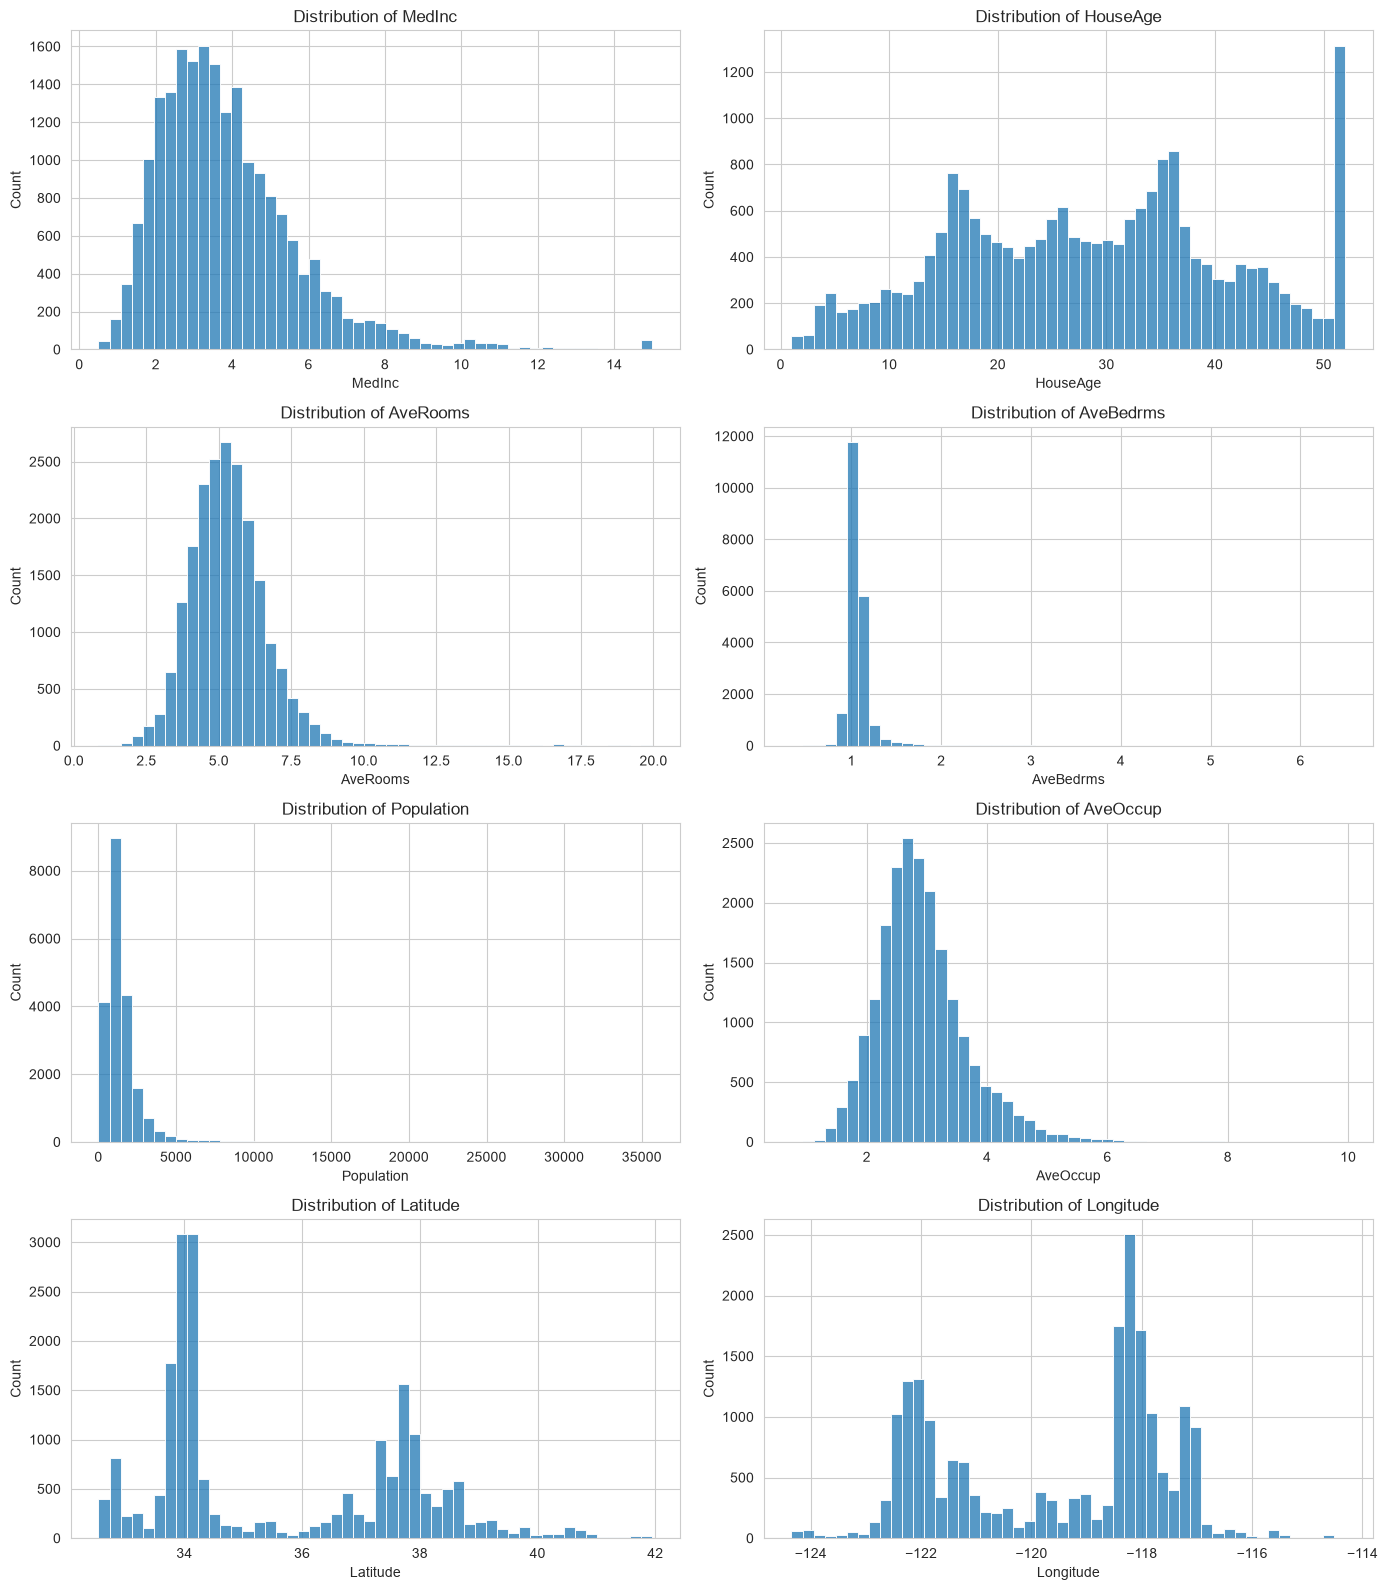

In [28]:
numeric_cols = df_clean.columns.drop('MedHouseVal')

fig, axes = plt.subplots(4, 2, figsize=(14, 16))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.histplot(df_clean[col], bins=50, ax=axes[i])
    axes[i].set_title(f'Distribution of {col}')

plt.tight_layout()
plt.savefig('outputs/feature_distributions.png', dpi=150)
plt.show()

<Axes: xlabel='Population', ylabel='Count'>

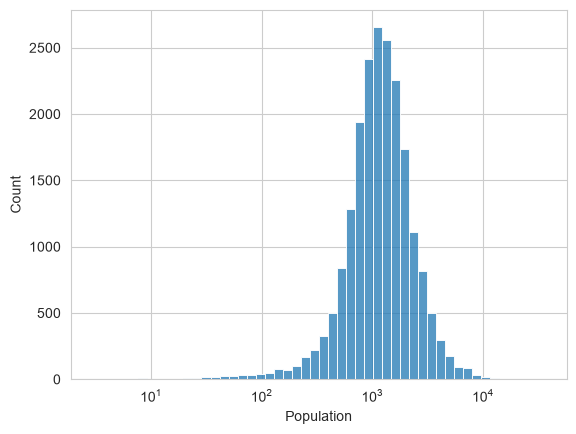

In [29]:
    sns.histplot(df_clean['Population'], bins=50, log_scale=True)

**Notes to fill in after viewing the plots:**
- Which features look right-skewed and might benefit from a log transform (e.g. `AveRooms`, `AveBedrms`, `AveOccup`, `Population` are common candidates)?
- Does `HouseAge` show a cap (similar to the target) at a max value?

In [32]:
print(df_clean['HouseAge'].max())
capped_age = (df_clean['HouseAge'] >= df_clean['HouseAge'].max()).sum()
print(f"Rows at the cap: {capped_age} ({capped_age/len(df_clean)*100:.2f}%)")

52.0
Rows at the cap: 1266 (6.17%)


In [33]:
df_clean['is_max_house_age'] = (df_clean['HouseAge'] == 52).astype(int)

# Sanity check
print(df_clean['is_max_house_age'].value_counts())

is_max_house_age
0    19269
1     1266
Name: count, dtype: int64


## 9. Correlation with Target

In [34]:
df_clean['bedroom_ratio'] = df_clean['AveBedrms'] / df_clean['AveRooms']

df_clean = df_clean.drop(columns=['AveBedrms'])

# Sanity check
df_clean[['AveRooms', 'bedroom_ratio']].describe()

,AveRooms,bedroom_ratio
count,20535.000000,20535.000000
mean,5.335105,0.213050
std,1.420036,0.057769
min,0.846154,0.100000
25%,4.438131,0.175433
50%,5.225127,0.203187
75%,6.041772,0.239849
max,19.962121,1.000000


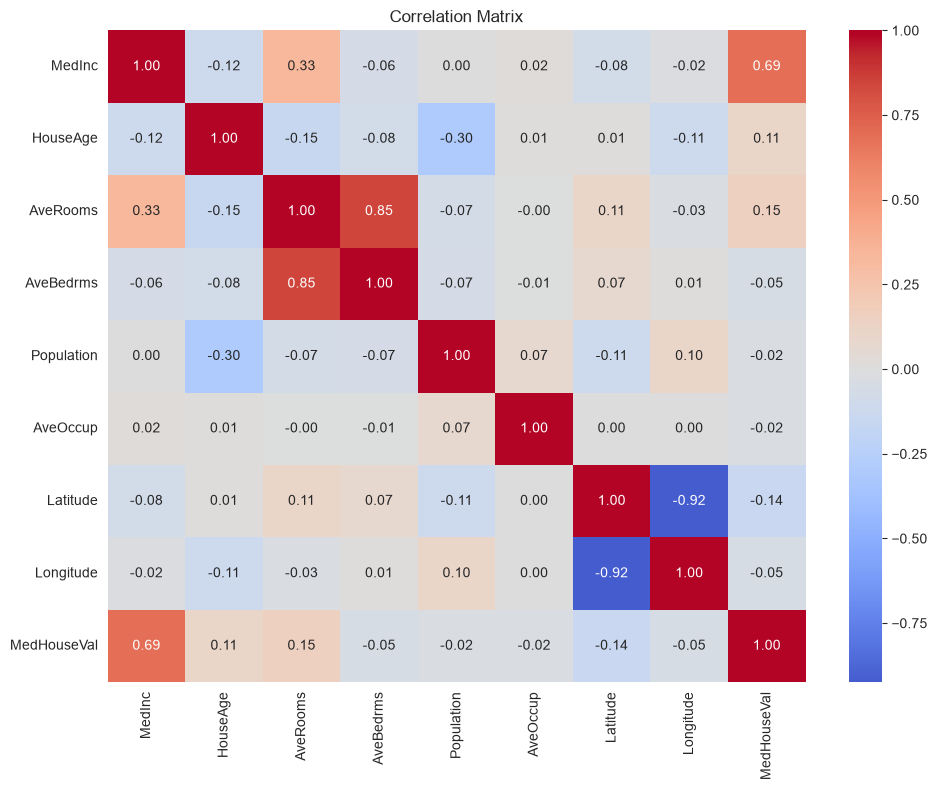

In [35]:
corr_matrix = df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.savefig('outputs/correlation_heatmap.png', dpi=150)
plt.show()

In [36]:
corr_matrix['MedHouseVal'].sort_values(ascending=False)

MedHouseVal    1.000000
MedInc         0.688075
AveRooms       0.151948
HouseAge       0.105623
AveOccup      -0.023737
Population    -0.024650
Longitude     -0.045967
AveBedrms     -0.046701
Latitude      -0.144160
Name: MedHouseVal, dtype: float64

## 10. Geographic Distribution

California Housing is inherently spatial — `Latitude`/`Longitude` likely matter a lot. Plotting price by location is one of the most informative views for this dataset.

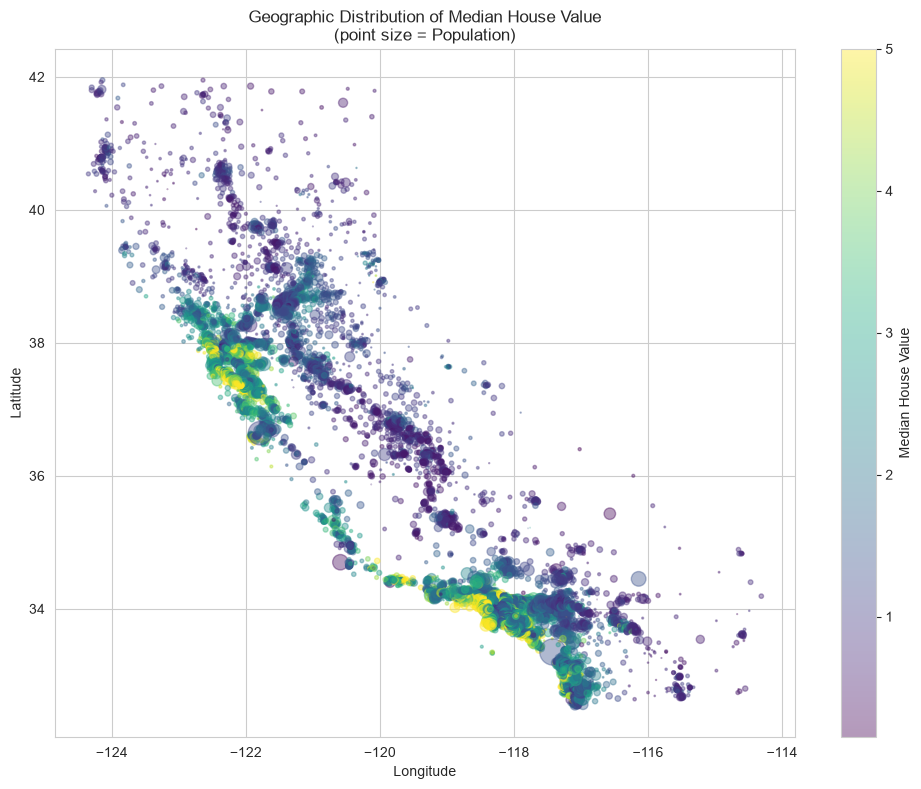

In [37]:
plt.figure(figsize=(10, 8))
scatter = plt.scatter(
    df['Longitude'], df['Latitude'],
    c=df['MedHouseVal'], cmap='viridis',
    s=df['Population'] / 100, alpha=0.4
)
plt.colorbar(scatter, label='Median House Value')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Geographic Distribution of Median House Value\n(point size = Population)')
plt.tight_layout()
plt.savefig('outputs/geo_price_distribution.png', dpi=150)
plt.show()

## 11. Outlier Check on Key Ratio Features

In [38]:
for col in ['AveRooms', 'AveBedrms', 'AveOccup']:
    print(f"--- {col} ---")
    print(df[col].describe())
    print(f"Top 5 highest values:\n{df[col].nlargest(5)}\n")

--- AveRooms ---
count    20640.000000
mean         5.429000
std          2.474173
min          0.846154
25%          4.440716
50%          5.229129
75%          6.052381
max        141.909091
Name: AveRooms, dtype: float64
Top 5 highest values:
1914     141.909091
1979     132.533333
12447     62.422222
1913      61.812500
11862     59.875000
Name: AveRooms, dtype: float64

--- AveBedrms ---
count    20640.000000
mean         1.096675
std          0.473911
min          0.333333
25%          1.006079
50%          1.048780
75%          1.099526
max         34.066667
Name: AveBedrms, dtype: float64
Top 5 highest values:
1979     34.066667
1914     25.636364
11862    15.312500
12447    14.111111
9676     11.410714
Name: AveBedrms, dtype: float64

--- AveOccup ---
count    20640.000000
mean         3.070655
std         10.386050
min          0.692308
25%          2.429741
50%          2.818116
75%          3.282261
max       1243.333333
Name: AveOccup, dtype: float64
Top 5 highest values:


## 12. Summary of Findings (fill in after running this notebook)

- **Missing values:** 
- **Duplicates:** 
- **Target distribution / capping:** 
- **Skewed features (candidates for transformation):** 
- **Strongest correlations with `MedHouseVal`:** 
- **Outliers worth addressing in preprocessing:** 
- **Geographic patterns observed:** 

**Next notebook:** `02_data_preprocessing.ipynb` — handle outliers/transformations identified above, feature engineering (e.g. rooms-per-household-style ratios if useful), train/test split, scaling.